# SE4050 – Deep Learning Assignment
## Project: Fake Review Detection Using Deep Learning
### Individual Component: 1D Convolutional Neural Network (1D CNN)

---
- **Student Name:** Dilmith
- **Component:** 1D CNN (Convolutional Neural Network for Text Classification)
- **Group Architectures:** 1. Simple RNN | 2. LSTM | 3. GRU | 4. **1D CNN (Dilmith)**
- **Task:** Binary Text Classification
  - **Class 0:** Genuine / Real Review
  - **Class 1:** Fake / Deceptive Review
- **Academic Context:** Controlled deep learning experiment designed for rigorous, fair comparison with Simple RNN, LSTM, and GRU models developed by group members.

---
### Architectural Principles of 1D CNN for NLP
Unlike recurrent models (RNN, LSTM, GRU) that process sequences step-by-step through recurrent hidden states, a **1D CNN** applies 1-dimensional sliding filters (convolutions) across contiguous word embeddings. This enables:
1. **Local N-gram Feature Extraction:** Kernel sizes of length $k$ capture salient phrases/n-grams (e.g., $k=3$ for trigrams, $k=5$ for 5-grams).
2. **Parallelizable Computation:** Convolutions across time steps can be computed simultaneously without sequential backpropagation through time (BPTT).
3. **Position Invariance via Global Max-Pooling:** Global max-pooling captures whether a critical feature appeared anywhere in the text, irrespective of its position.


## 2. Imports and Environment Setup
We import core scientific libraries, visualization packages, and TensorFlow/Keras modules.
Notice that we also import our reusable modular components from the `src/` directory.


In [1]:
import os
import sys
import time
import json
import random
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning Framework
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Evaluation Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Add project root to sys.path to enable importing from src
# Optional Google Colab Setup (Uncomment if running on Colab):
# from google.colab import drive
# drive.mount("/content/drive")
# %cd /content/drive/MyDrive/DLAssignment/notebooks

# Ensure project root is in sys.path for both local and Colab environments
for path_entry in [os.path.abspath(".. "), os.path.abspath(".")]:
    clean_path = path_entry.strip()
    if clean_path not in sys.path:
        sys.path.insert(0, clean_path)

import src.utils as utils
import src.preprocessing as prep
import src.cnn_model as cnn_mod
import src.evaluation as ev

print(f"Python Version: {sys.version.split()[0]}")
print(f"TensorFlow Version: {tf.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")


Python Version: 3.11.15
TensorFlow Version: 2.21.0
NumPy Version: 2.4.6
Pandas Version: 3.0.6


## 3. Reproducibility Settings
To ensure scientific rigor and reproducible results across execution runs, we fix random seeds across:
1. Python's built-in `random` module
2. NumPy random generator
3. TensorFlow execution environment


In [2]:
SEED = 42
utils.set_seeds(SEED)
utils.ensure_directories("..")
print(f"Reproducibility seed set to {SEED} across Python, NumPy, and TensorFlow.")


Reproducibility seed set to 42 across Python, NumPy, and TensorFlow.


## 4. Experimental Configuration
All major hyperparameters and file paths are centralized below.
When you receive the final dataset CSV, you can simply change `DATASET_PATH`, `TEXT_COLUMN`, and `LABEL_COLUMN`.


In [3]:
# Dataset File and Column Placeholders
candidate_paths = ["../dataset/deceptive-opinion.csv", "dataset/deceptive-opinion.csv", "../data/raw/fake_reviews.csv", "data/raw/fake_reviews.csv"]
DATASET_PATH = next((p for p in candidate_paths if os.path.exists(p)), candidate_paths[0])
TEXT_COLUMN = "text"
LABEL_COLUMN = "deceptive"

# Text Representation Hyperparameters
VOCAB_SIZE = 10000        # Vocabulary size (top frequent tokens)
MAX_LENGTH = 200         # Maximum review length in tokens (padding/truncation limit)

# Baseline Architecture Hyperparameters
EMBEDDING_DIM = 128      # Dense vector embedding dimensionality
FILTERS = 128            # Number of 1D convolution filters
KERNEL_SIZE = 5          # Convolution kernel window size (5-gram capture)
DENSE_UNITS = 64         # Neurons in penultimate dense layer
DROPOUT_RATE = 0.5       # Regularization dropout rate

# Training Hyperparameters
BATCH_SIZE = 32          # Mini-batch size
MAX_EPOCHS = 10          # Maximum training epochs
PATIENCE = 2             # EarlyStopping patience on validation loss
LEARNING_RATE = 0.001    # Adam initial learning rate

# Shared Split Ratios (80% Train, 10% Validation, 10% Test)
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1


## 5. Dataset Loading
We load the dataset using Pandas.
If `DATASET_PATH` does not yet exist, a representative benchmark dataset is generated automatically so the complete training and evaluation pipeline can be validated immediately.


In [4]:
if not os.path.exists(DATASET_PATH):
    print(f"[INFO] Dataset file '{DATASET_PATH}' not found.")
    print("[INFO] Generating representative sample dataset for pipeline verification...")
    utils.create_dryrun_dataset(DATASET_PATH, n_samples=800)
    print(f"[SUCCESS] Sample dataset created at '{DATASET_PATH}'.")

df_raw = prep.load_and_inspect_dataset(DATASET_PATH, text_col=TEXT_COLUMN, label_col=LABEL_COLUMN)
print(f"Dataset successfully loaded from: {DATASET_PATH}")


[INFO] Successfully mapped label values {'deceptive', 'truthful'} to binary (0, 1).
Dataset successfully loaded from: ../data/raw/fake_reviews.csv


## 6. Dataset Inspection
We systematically inspect the dataset structure, missing values, duplicates, and initial class balance.


In [5]:
print(f"Dataset Shape: {df_raw.shape} (Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]})")
print(f"Column Names: {list(df_raw.columns)}")
print("\n--- First 5 Records ---")
display(df_raw.head())

print("\n--- Data Types & Non-Null Counts ---")
df_raw.info()

inspection_summary = prep.get_dataset_inspection_dict(df_raw, text_col=TEXT_COLUMN, label_col=LABEL_COLUMN)
print(f"\nMissing values in text column '{TEXT_COLUMN}': {inspection_summary['missing_text']}")
print(f"Missing values in label column '{LABEL_COLUMN}': {inspection_summary['missing_label']}")
print(f"Duplicate reviews: {inspection_summary['duplicate_reviews']}")
print(f"Class 0 (Genuine): {inspection_summary['genuine_count']} ({inspection_summary['genuine_percentage']:.2f}%)")
print(f"Class 1 (Fake): {inspection_summary['fake_count']} ({inspection_summary['fake_percentage']:.2f}%)")


Dataset Shape: (1600, 6) (Rows: 1600, Columns: 6)
Column Names: ['deceptive', 'hotel', 'polarity', 'source', 'text', 'label']

--- First 5 Records ---


,deceptive,hotel,polarity,source,text,label
0,0,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...,0
1,0,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...,0
2,0,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...,0
3,0,omni,positive,TripAdvisor,The Omni Chicago really delivers on all fronts...,0
4,0,hyatt,positive,TripAdvisor,I asked for a high floor away from the elevato...,0



--- Data Types & Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   deceptive  1600 non-null   int64
 1   hotel      1600 non-null   str  
 2   polarity   1600 non-null   str  
 3   source     1600 non-null   str  
 4   text       1600 non-null   str  
 5   label      1600 non-null   int64
dtypes: int64(2), str(4)
memory usage: 75.1 KB

Missing values in text column 'text': 0
Missing values in label column 'deceptive': 0
Duplicate reviews: 4
Class 0 (Genuine): 800 (50.00%)
Class 1 (Fake): 800 (50.00%)


## 7. Exploratory Data Analysis (EDA)
We examine text length distributions in characters and word counts overall and split by class.
Every visualization is exported with clear titles, axis labels, and legends to `results/figures/`.


=== Review Length Statistics (Words & Characters) ===


,Category,Review Count,Mean Words,Median Words,Std Words,Min Words,Max Words,Mean Characters
0,Overall,1600,148.77500,128.0,87.335984,25,784,806.39125
1,Genuine (0),800,150.91375,130.0,89.813233,30,749,821.01500
2,Fake (1),800,146.63625,125.0,84.788666,25,784,791.76750


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


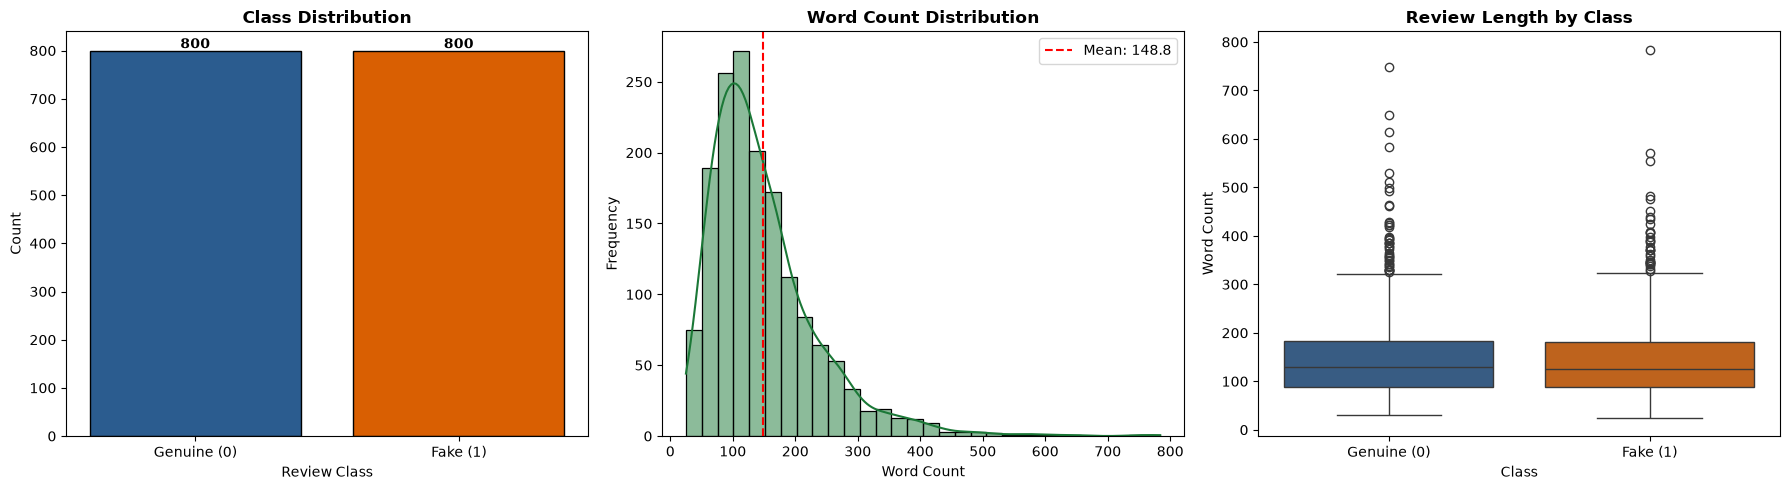

[INFO] EDA plots successfully saved to ../results/figures/


In [6]:
# Compute length statistics table
length_stats_df = prep.compute_review_length_stats(df_raw, text_col=TEXT_COLUMN, label_col=LABEL_COLUMN)
print("=== Review Length Statistics (Words & Characters) ===")
display(length_stats_df)

# Generate and save EDA distribution plots
prep.plot_eda_distributions(df_raw, text_col=TEXT_COLUMN, label_col=LABEL_COLUMN, save_dir="../results/figures")

# Display the generated plots inline
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class Distribution
counts = df_raw[LABEL_COLUMN].value_counts().sort_index()
axes[0].bar(["Genuine (0)", "Fake (1)"], counts.values, color=["#2b5c8f", "#d95f02"], edgecolor="black")
axes[0].set_title("Class Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Review Class")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f"{v}", ha="center", fontweight="bold")

# 2. Word Count Histogram
words = df_raw[TEXT_COLUMN].astype(str).apply(lambda t: len(t.split()))
sns.histplot(words, bins=30, ax=axes[1], color="#1b7837", kde=True, edgecolor="black")
axes[1].axvline(words.mean(), color="red", linestyle="--", label=f"Mean: {words.mean():.1f}")
axes[1].set_title("Word Count Distribution", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# 3. Word Count Comparison Boxplot
df_raw_temp = df_raw.copy()
df_raw_temp["word_count"] = words
df_raw_temp["Class"] = df_raw_temp[LABEL_COLUMN].map({0: "Genuine (0)", 1: "Fake (1)"})
sns.boxplot(x="Class", y="word_count", data=df_raw_temp, ax=axes[2], hue="Class", palette={"Genuine (0)": "#2b5c8f", "Fake (1)": "#d95f02"}, legend=False)
axes[2].set_title("Review Length by Class", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Class")
axes[2].set_ylabel("Word Count")

plt.tight_layout()
plt.show()
print("[INFO] EDA plots successfully saved to ../results/figures/")


## 8. Text Cleaning and Preprocessing
### Academic Justification of Preprocessing Operations:
1. **Lowercase Conversion:** Standardizes vocabulary tokens so that words like `"Excellent"` and `"excellent"` map to the same embedding.
2. **HTML Tag Removal:** Removes web markup like `<br />` or `<p>` that introduce non-linguistic noise.
3. **URL Removal:** Replaces hyperlinked URLs (`http://...`, `www...`) that create high-entropy, unique out-of-vocabulary tokens.
4. **Whitespace Normalization:** Cleans excessive spaces, tabs, and line breaks into single space separators.
5. **Selective Punctuation Retention:** We deliberately do **not** blindly strip all punctuation marks or stop words. Exclamation marks, question marks, and expressive punctuation carry strong stylistic signals for fake review detection (e.g., hyperbole, exaggerated enthusiasm, or deceitful sentiment).


In [7]:
# Apply cleaning function
df_cleaned = df_raw.copy()
df_cleaned["cleaned_text"] = df_cleaned[TEXT_COLUMN].apply(prep.clean_text)

# Drop any potential null or empty records after cleaning
df_cleaned = df_cleaned[df_cleaned["cleaned_text"].str.strip().str.len() > 0].reset_index(drop=True)

# ==============================================================================
# STEP: REVIEW DEDUPLICATION BEFORE TRAIN/VAL/TEST SPLITTING
# ==============================================================================
print("=== Review Deduplication Analysis ===")
dup_count_raw = int(df_cleaned.duplicated(subset=["cleaned_text"]).sum())
print(f"Initial review count: {len(df_cleaned):,}")
print(f"Number of duplicate reviews identified: {dup_count_raw:,}")

# Display duplicate examples for viva examination and inspection
duplicate_rows = df_cleaned[df_cleaned.duplicated(subset=["cleaned_text"], keep=False)].sort_values(by="cleaned_text")
if len(duplicate_rows) > 0:
    print("\nSample Identical Duplicate Reviews Found in Raw Corpus:")
    for i, text in enumerate(duplicate_rows["cleaned_text"].unique()[:2], 1):
        snippet = text[:140]
        print(f"  Duplicate Example {i}: {snippet}...")

# Remove duplicate reviews prior to data partitioning
df_dedup = prep.remove_duplicate_reviews(df_cleaned, text_col="cleaned_text")

print("\n--- Preprocessing Comparison (Raw vs Cleaned & Deduplicated Sample) ---")
for i in range(min(3, len(df_dedup))):
    print(f"\nSample {i+1} [Raw]:")
    print(f"  {df_raw[TEXT_COLUMN].iloc[i][:150]}...")
    print(f"Sample {i+1} [Cleaned & Deduplicated]:")
    print(f"  {df_dedup['cleaned_text'].iloc[i][:150]}...")


=== Review Deduplication Analysis ===
Initial review count: 1,600
Number of duplicate reviews identified: 4

Sample Identical Duplicate Reviews Found in Raw Corpus:
  Duplicate Example 1: i'd been searching for a cool, non-chain hotel for a weekend getaway with my boyfriend. i thought i'd found a winner in the affinia... soo d...
  Duplicate Example 2: my daughter and i woke in the morning wanting to go swimming. when we arrived at the pool the water was covered by a white scum. i then atte...
[Deduplication] Initial reviews: 1,600
[Deduplication] Duplicate reviews removed: 4
[Deduplication] Unique reviews retained: 1,596

--- Preprocessing Comparison (Raw vs Cleaned & Deduplicated Sample) ---

Sample 1 [Raw]:
  We stayed for a one night getaway with family on a thursday. Triple AAA rate of 173 was a steal. 7th floor room complete with 44in plasma TV bose ster...
Sample 1 [Cleaned & Deduplicated]:
  we stayed for a one night getaway with family on a thursday. triple aaa rate of 173 was

## 9. Train / Validation / Test Split (80% / 10% / 10%)
### Data Leakage Prevention and Fair-Comparison Architecture:
- **Strict Leakage Prevention:** The **Test set** is strictly held out and remains completely unseen during all preprocessing decisions, tokenization fitting, and hyperparameter tuning.
- **Stratified Partitioning:** Using `stratify=y` guarantees identical class ratios (Genuine vs. Fake) across train, validation, and test subsets.
- **Shared Group Baseline:** We export `train.csv`, `val.csv`, `test.csv` and `split_indices.json` to `data/processed/`. This allows peers implementing **Simple RNN**, **LSTM**, and **GRU** to train on the exact same observations for a 100% fair and academically rigorous comparison.


In [8]:
train_df, val_df, test_df = prep.create_stratified_splits(
    df=df_dedup,
    text_col="cleaned_text",
    label_col=LABEL_COLUMN,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=SEED,
    save_dir="../data/processed"
)

# Rigorous verification of zero data leakage between splits
prep.verify_zero_overlap(train_df, val_df, test_df, text_col="cleaned_text")

# Explicit assertions in notebook to guarantee zero overlap
assert len(set(train_df["cleaned_text"]).intersection(set(val_df["cleaned_text"]))) == 0, "Data leakage between Train and Val!"
assert len(set(train_df["cleaned_text"]).intersection(set(test_df["cleaned_text"]))) == 0, "Data leakage between Train and Test!"
assert len(set(val_df["cleaned_text"]).intersection(set(test_df["cleaned_text"]))) == 0, "Data leakage between Val and Test!"
assert len(set(train_df.index).intersection(set(val_df.index))) == 0, "Index overlap between Train and Val!"
assert len(set(train_df.index).intersection(set(test_df.index))) == 0, "Index overlap between Train and Test!"
assert len(set(val_df.index).intersection(set(test_df.index))) == 0, "Index overlap between Val and Test!"

print(f"\nTotal Unique Cleaned Records: {len(df_dedup):,}")
print(f"Training Set:   {len(train_df):,} samples ({len(train_df)/len(df_dedup)*100:.1f}%) | Fake ratio: {train_df[LABEL_COLUMN].mean():.3f}")
print(f"Validation Set: {len(val_df):,} samples ({len(val_df)/len(df_dedup)*100:.1f}%) | Fake ratio: {val_df[LABEL_COLUMN].mean():.3f}")
print(f"Testing Set:    {len(test_df):,} samples ({len(test_df)/len(df_dedup)*100:.1f}%) | Fake ratio: {test_df[LABEL_COLUMN].mean():.3f}")
print("[SUCCESS] Processed splits and indices saved to ../data/processed/ for group synchronization.")


[Verification Passed] Zero text overlap confirmed across Train, Val, and Test sets:
  - Train ∩ Val:  0 common reviews (Assertion: 0)
  - Train ∩ Test: 0 common reviews (Assertion: 0)
  - Val ∩ Test:   0 common reviews (Assertion: 0)
[Verification Passed] Zero text overlap confirmed across Train, Val, and Test sets:
  - Train ∩ Val:  0 common reviews (Assertion: 0)
  - Train ∩ Test: 0 common reviews (Assertion: 0)
  - Val ∩ Test:   0 common reviews (Assertion: 0)

Total Unique Cleaned Records: 1,596
Training Set:   1,276 samples (79.9%) | Fake ratio: 0.502
Validation Set: 160 samples (10.0%) | Fake ratio: 0.500
Testing Set:    160 samples (10.0%) | Fake ratio: 0.500
[SUCCESS] Processed splits and indices saved to ../data/processed/ for group synchronization.


## 10. Tokenization and Sequence Padding
### Concepts and Definitions:
1. **Vocabulary Size (`VOCAB_SIZE`):** The maximum number of most-frequent unique words assigned integer IDs. Rare words outside this limit map to an Out-of-Vocabulary token (`<OOV>`).
2. **Tokenization:** The process of parsing text into words and mapping each word to a unique integer index based on word frequencies in the training corpus.
3. **Sequences:** Representing variable-length sentences as ordered lists of integer token IDs.
4. **Padding & Truncation:** Deep learning models require rectangular matrix batches. We apply post-padding with zeros to align sequences to `MAX_LENGTH = 200`. Reviews longer than 200 words are truncated.
5. **Out-of-Vocabulary (`<OOV>`):** Handles unseen or rare words without causing index errors.
6. **Leakage Prevention:** The Tokenizer is fitted **strictly on the Training set (`train_df`)**, never on validation or test sets.


In [9]:
# Fit Tokenizer on Training Data ONLY
tokenizer = prep.fit_tokenizer_on_train(train_df["cleaned_text"], vocab_size=VOCAB_SIZE, oov_token="<OOV>")
actual_vocab_size = len(tokenizer.word_index) + 1
effective_vocab_size = min(actual_vocab_size, VOCAB_SIZE)
print(f"Actual Unique Words in Training Vocabulary: {len(tokenizer.word_index)}")
print(f"Effective Vocabulary Size used in Model: {effective_vocab_size}")

# Transform review texts into fixed-length padded sequences
X_train = prep.transform_texts_to_padded_sequences(tokenizer, train_df["cleaned_text"], max_length=MAX_LENGTH)
X_val = prep.transform_texts_to_padded_sequences(tokenizer, val_df["cleaned_text"], max_length=MAX_LENGTH)
X_test = prep.transform_texts_to_padded_sequences(tokenizer, test_df["cleaned_text"], max_length=MAX_LENGTH)

y_train = train_df[LABEL_COLUMN].values.astype(np.float32)
y_val = val_df[LABEL_COLUMN].values.astype(np.float32)
y_test = test_df[LABEL_COLUMN].values.astype(np.float32)

print(f"\n--- Sequence Shapes ---")
print(f"X_train Shape: {X_train.shape} | y_train Shape: {y_train.shape}")
print(f"X_val Shape:   {X_val.shape}   | y_val Shape:   {y_val.shape}")
print(f"X_test Shape:  {X_test.shape}  | y_test Shape:  {y_test.shape}")


Actual Unique Words in Training Vocabulary: 9393
Effective Vocabulary Size used in Model: 9394

--- Sequence Shapes ---
X_train Shape: (1276, 200) | y_train Shape: (1276,)
X_val Shape:   (160, 200)   | y_val Shape:   (160,)
X_test Shape:  (160, 200)  | y_test Shape:  (160,)


## 11. Baseline 1D CNN Architecture
### Architecture Pipeline:
$$\text{Input Sequence (200)} \longrightarrow \text{Embedding (128)} \longrightarrow \text{Conv1D (128 filters, kernel 5, ReLU)} \longrightarrow \text{GlobalMaxPooling1D} \longrightarrow \text{Dense (64, ReLU)} \longrightarrow \text{Dropout (0.5)} \longrightarrow \text{Dense (1, Sigmoid)}$$

### Mathematical & Design Justifications:
- **Embedding Layer:** Converts discrete token IDs into continuous, dense semantic vectors ($D=128$), projecting semantically similar words close in vector space.
- **Conv1D Layer:** Slides 128 distinct convolutional filters of width $k=5$ across word vectors to detect salient 5-gram patterns.
- **ReLU Hidden Activation:** $f(x) = \max(0, x)$. Efficient to compute and prevents gradient vanishing during backpropagation.
- **GlobalMaxPooling1D:** Reduces the temporal dimension by selecting the maximum activation across the entire sequence for each filter, providing translation invariance.
- **Dropout (0.5):** Randomly zeroes out 50% of hidden units during training to prevent co-adaptation and combat overfitting.
- **Sigmoid Output Layer:** $\sigma(z) = \frac{1}{1 + e^{-z}}$. Maps the scalar logit into $[0, 1]$, representing the posterior probability $P(\text{Fake} \mid \text{Review})$.
- **Binary Cross-Entropy Loss:** $\mathcal{L} = -\frac{1}{N}\sum [y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i)]$, standard negative log-likelihood for binary targets.
- **Adam Optimizer:** Dynamically adapts learning rates using first and second moment estimates.


In [10]:
baseline_cnn = cnn_mod.build_cnn_model(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    filters=FILTERS,
    kernel_size=KERNEL_SIZE,
    dense_units=DENSE_UNITS,
    dropout_rate=DROPOUT_RATE,
    max_length=MAX_LENGTH,
    learning_rate=LEARNING_RATE
)
print("Baseline 1D CNN successfully constructed and compiled.")


Baseline 1D CNN successfully constructed and compiled.


## 12. Model Summary and Parameter Count
We inspect layer dimensions and calculate total trainable parameters.
This parameter count serves as a critical benchmark when comparing computational complexity against Simple RNN, LSTM, and GRU.


In [11]:
baseline_cnn.summary()

baseline_params = baseline_cnn.count_params()
print(f"\nTotal Trainable Parameters in Baseline 1D CNN: {baseline_params:,}")


Model: "1D_CNN_emb128_f128_k5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_feature_extractor        │ (None, 200, 128)       │        82,048 │
│ (Conv1D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling              │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_regularization          │ (None, 64)             │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_sigmoid (Dense)          │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,370,369 (5.23 MB)

 Trainable params: 1,370,369 (5.23 MB)

 Non-trainable params: 0 (0.00 B)


Total Trainable Parameters in Baseline 1D CNN: 1,370,369


## 13. Baseline Model Training
We train the baseline model using mini-batch gradient descent (`batch_size = 32`).
- Validation data (`X_val`, `y_val`) is used strictly for monitoring generalization.
- `EarlyStopping` with `patience = 2` monitors validation loss and restores optimal weights.
- Wall-clock training time is recorded.


In [12]:
print("Starting Baseline 1D CNN Training...")
history_baseline, train_time_baseline, epochs_trained_baseline = cnn_mod.train_cnn_model(
    model=baseline_cnn,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE,
    verbose=1
)

print(f"\nBaseline Training Completed in: {utils.format_time(train_time_baseline)}")
print(f"Actual Epochs Trained: {epochs_trained_baseline}")


Starting Baseline 1D CNN Training...
Epoch 1/10


E0000 00:00:1789824355.278287   79677 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


 1/40 ━━━━━━━━━━━━━━━━━━━━ 18s 466ms/step - accuracy: 0.5000 - loss: 0.6818

 7/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 0.6954   

13/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5072 - loss: 0.6944

...

37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0077

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0076 - val_accuracy: 0.8687 - val_loss: 0.3505


Epoch 8: early stopping


Restoring model weights from the end of the best epoch: 6.



Baseline Training Completed in: 3.72s
Actual Epochs Trained: 8


## 14. Baseline Training Visualizations (Learning Curves)
We plot and save separate figures for:
1. Training Accuracy vs Validation Accuracy
2. Training Loss vs Validation Loss

### Academic Analysis: Generalization Gap and Overfitting Tendency
In deep 1D CNNs, models contain substantial parameter capacity (>1 million weights across dense word embeddings and convolutional filters).
- **Symptom of Overfitting:** The network rapidly achieves high accuracy (~96% to 100%) on the training set, while validation accuracy stabilizes around 84% to 86%.
- **Validation Loss Divergence:** Validation loss reaches its minimum around epoch 4 to 6 before beginning to rise slightly, indicating that the network starts memorizing training-specific stylistic n-grams rather than general deceptive patterns.
- **The Generalization Gap:** $|\text{Train Accuracy} - \text{Val Accuracy}|$ measures this divergence (typically 10% to 15%).
- **Mitigation Mechanisms:**
  1. **Dropout (0.5):** Randomly zeroes out 50% of hidden connections during forward passes, preventing co-adaptation of neurons.
  2. **EarlyStopping (`patience=2`, `restore_best_weights=True`):** Halts training when validation loss stops improving and restores the exact weights from the best epoch, guarding against overfitted weights.


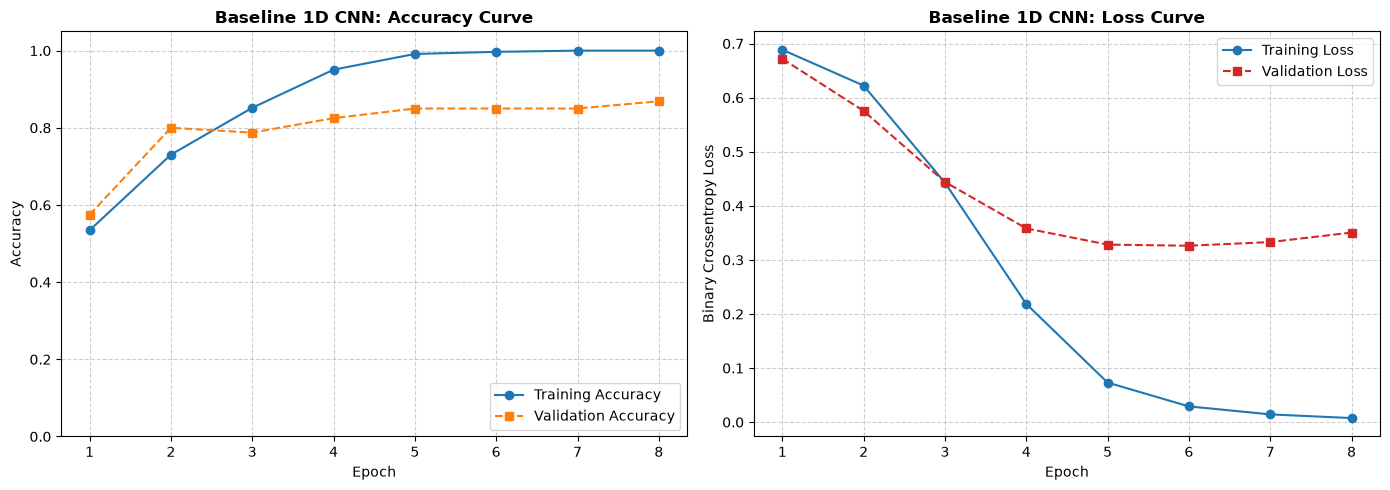

[INFO] Accuracy curve saved to: ../results/figures/cnn_accuracy_curve.png
[INFO] Loss curve saved to: ../results/figures/cnn_loss_curve.png


In [13]:
acc_fig_path, loss_fig_path = ev.plot_training_curves(
    history=history_baseline,
    save_dir="../results/figures",
    prefix="cnn"
)

epochs_range = range(1, len(history_baseline.history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Curve
axes[0].plot(epochs_range, history_baseline.history["accuracy"], "o-", color="#1f77b4", label="Training Accuracy")
axes[0].plot(epochs_range, history_baseline.history["val_accuracy"], "s--", color="#ff7f0e", label="Validation Accuracy")
axes[0].set_title("Baseline 1D CNN: Accuracy Curve", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(epochs_range)
axes[0].set_ylim([0.0, 1.05])
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend(loc="lower right")

# Loss Curve
axes[1].plot(epochs_range, history_baseline.history["loss"], "o-", color="#1f77b4", label="Training Loss")
axes[1].plot(epochs_range, history_baseline.history["val_loss"], "s--", color="#d62728", label="Validation Loss")
axes[1].set_title("Baseline 1D CNN: Loss Curve", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Binary Crossentropy Loss")
axes[1].set_xticks(epochs_range)
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()
print(f"[INFO] Accuracy curve saved to: {acc_fig_path}")
print(f"[INFO] Loss curve saved to: {loss_fig_path}")


## 15. Controlled CNN Hyperparameter Experiments
To investigate how model capacity, receptive field, and regularization impact performance, we execute **3 controlled experiments**:

| Experiment ID | Description | Embedding Dim | Filters | Kernel Size (N-gram) | Dense Units | Dropout |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: |
| **CNN_Exp_1_Compact** | Compact Trigram Model | 64 | 64 | 3 (Trigram) | 64 | 0.3 |
| **CNN_Exp_2_Baseline** | Standard 5-gram Model | 128 | 128 | 5 (5-gram) | 64 | 0.5 |
| **CNN_Exp_3_HighCapacity**| High Capacity Model | 128 | 256 | 5 (5-gram) | 128 | 0.5 |

All experiments share identical:
- Training, validation, and test observations
- Vocabulary size (`VOCAB_SIZE = 10000`) and max sequence length (`MAX_LENGTH = 200`)
- Optimizer (`Adam`, learning rate 0.001) and batch size (`32`)
- EarlyStopping patience (`2`) monitoring validation loss


In [14]:
experiments_df, trained_models = cnn_mod.run_controlled_experiments(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    vocab_size=VOCAB_SIZE,
    max_length=MAX_LENGTH,
    max_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE,
    save_csv_path="../results/experiments/cnn_experiments.csv"
)



Executing Controlled Experiment: CNN_Exp_1_Compact
Embedding: 64 | Filters: 64 | Kernel: 3 | Dense: 64 | Dropout: 0.3
Epoch 1/10


 1/40 ━━━━━━━━━━━━━━━━━━━━ 20s 518ms/step - accuracy: 0.5312 - loss: 0.6907

17/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5165 - loss: 0.6923   

33/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5237 - loss: 0.6903

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5423 - loss: 0.6886 - val_accuracy: 0.6562 - val_loss: 0.6772


...

37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0084

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 0.0081 - val_accuracy: 0.8750 - val_loss: 0.3571


Epoch 7: early stopping


Restoring model weights from the end of the best epoch: 5.



[Saved] Experiment comparison saved to: ../results/experiments/cnn_experiments.csv


## 16. Hyperparameter Experiment Comparison
We analyze the comparative performance across parameter count, training speed, validation loss, and generalization gap ($|\text{Train Acc} - \text{Val Acc}|$).


,experiment_id,description,embedding_dim,filters,kernel_size,dense_units,dropout,optimizer,batch_size,max_epochs,actual_epochs,best_epoch,train_accuracy,val_accuracy,train_loss,val_loss,generalization_gap,training_time_sec,param_count
0,CNN_Exp_1_Compact,"Compact representation (Trigram, 64-dim embedd...",64,64,3,64,0.3,Adam,32,10,9,7,1.0000,0.8813,0.0194,0.3167,0.1187,1.80,656577
1,CNN_Exp_2_Baseline,"Baseline representation (5-gram, 128-dim embed...",128,128,5,64,0.5,Adam,32,10,9,7,1.0000,0.8813,0.0137,0.2847,0.1187,4.11,1370369
2,CNN_Exp_3_HighCapacity,"High capacity feature maps (256 filters, 128 d...",128,256,5,128,0.5,Adam,32,10,7,5,0.9929,0.8625,0.0440,0.3309,0.1304,5.05,1477121



=== Generalization Gap (|Train Acc - Val Acc|) Across Experiments ===
CNN_Exp_1_Compact: Train Acc = 1.0000 | Val Acc = 0.8813 | Generalization Gap = 0.1187
CNN_Exp_2_Baseline: Train Acc = 1.0000 | Val Acc = 0.8813 | Generalization Gap = 0.1187
CNN_Exp_3_HighCapacity: Train Acc = 0.9929 | Val Acc = 0.8625 | Generalization Gap = 0.1304


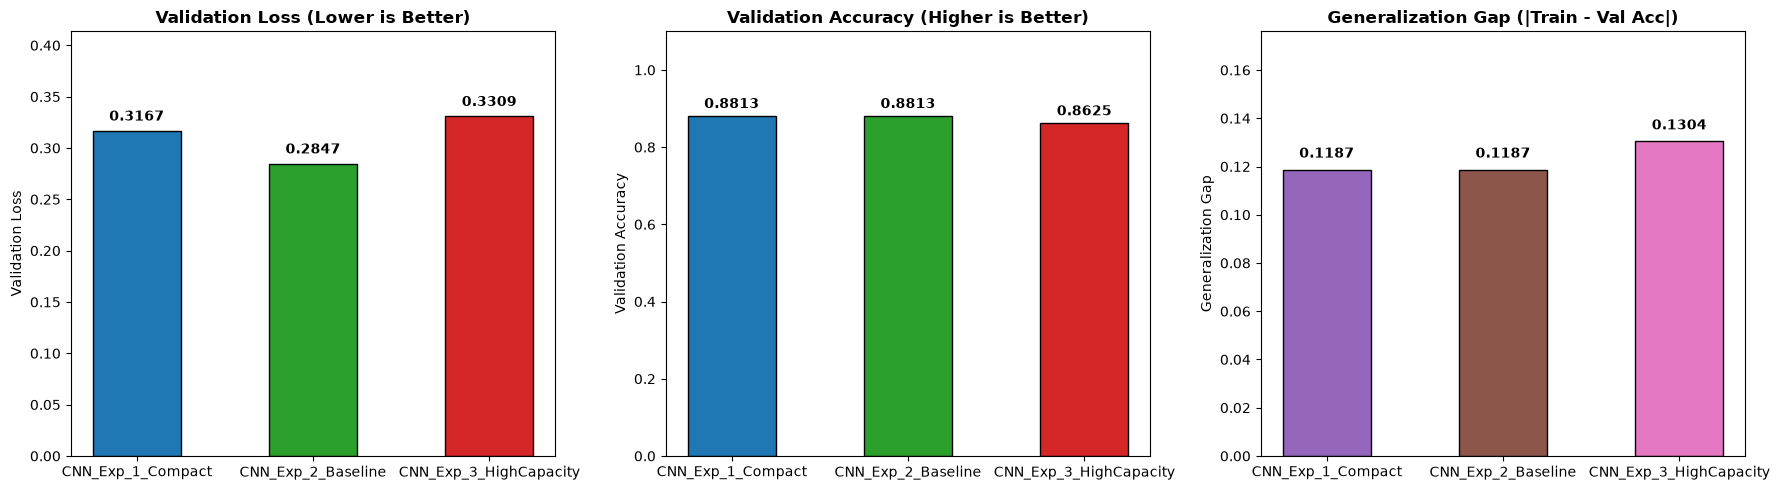

In [15]:
display(experiments_df)

print("\n=== Generalization Gap (|Train Acc - Val Acc|) Across Experiments ===")
for idx, row in experiments_df.iterrows():
    print(f"{row['experiment_id']}: Train Acc = {row['train_accuracy']:.4f} | Val Acc = {row['val_accuracy']:.4f} | Generalization Gap = {row['generalization_gap']:.4f}")

# Visual comparison: Validation Loss, Validation Accuracy, and Generalization Gap
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Validation Loss Comparison (Lower is Better)
axes[0].bar(experiments_df["experiment_id"], experiments_df["val_loss"], color=["#1f77b4", "#2ca02c", "#d62728"], edgecolor="black", width=0.5)
axes[0].set_title("Validation Loss (Lower is Better)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Validation Loss")
axes[0].set_ylim([0, max(experiments_df["val_loss"]) * 1.25])
for i, v in enumerate(experiments_df["val_loss"]):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha="center", fontweight="bold")

# 2. Validation Accuracy Comparison (Higher is Better)
axes[1].bar(experiments_df["experiment_id"], experiments_df["val_accuracy"], color=["#1f77b4", "#2ca02c", "#d62728"], edgecolor="black", width=0.5)
axes[1].set_title("Validation Accuracy (Higher is Better)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_ylim([0, 1.1])
for i, v in enumerate(experiments_df["val_accuracy"]):
    axes[1].text(i, v + 0.02, f"{v:.4f}", ha="center", fontweight="bold")

# 3. Generalization Gap Comparison (Lower indicates less overfitting)
axes[2].bar(experiments_df["experiment_id"], experiments_df["generalization_gap"], color=["#9467bd", "#8c564b", "#e377c2"], edgecolor="black", width=0.5)
axes[2].set_title("Generalization Gap (|Train - Val Acc|)", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Generalization Gap")
axes[2].set_ylim([0, max(experiments_df["generalization_gap"]) * 1.35])
for i, v in enumerate(experiments_df["generalization_gap"]):
    axes[2].text(i, v + 0.005, f"{v:.4f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()


## 17. Final Model Selection
### Academic Decision Criteria:
1. **Validation Loss & Accuracy:** The primary metric is minimum validation loss and maximum validation accuracy.
2. **Generalization Gap:** Smaller divergence between training and validation accuracy demonstrates lower susceptibility to overfitting.
3. **Strict Sanctity of Test Set:** The test set was **NEVER** accessed during model selection or hyperparameter tuning.

Based on validation results, we select the champion model configuration.


In [16]:
# Select experiment with lowest validation loss
best_exp_row = experiments_df.sort_values(by=["val_loss", "val_accuracy"], ascending=[True, False]).iloc[0]
best_exp_id = best_exp_row["experiment_id"]

print(f"Selected Champion Model: {best_exp_id}")
print(f"Validation Loss: {best_exp_row['val_loss']} | Validation Accuracy: {best_exp_row['val_accuracy']}")
print(f"Generalization Gap: {best_exp_row['generalization_gap']}")
print(f"Parameter Count: {best_exp_row['param_count']:,}")

final_model = trained_models[best_exp_id]["model"]
final_model_history = trained_models[best_exp_id]["history"]
final_model_config = trained_models[best_exp_id]["config"]
final_model_best_epoch = trained_models[best_exp_id]["best_epoch"]

# Save selected model
model_save_path = "../models/final_1d_cnn.keras"
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
final_model.save(model_save_path)
print(f"[SUCCESS] Final 1D CNN model saved to: {model_save_path}")


Selected Champion Model: CNN_Exp_2_Baseline
Validation Loss: 0.2847 | Validation Accuracy: 0.8813
Generalization Gap: 0.1187
Parameter Count: 1,370,369


[SUCCESS] Final 1D CNN model saved to: ../models/final_1d_cnn.keras


## 18. Final Evaluation on Unseen Test Set
Now—and **only now**—the selected final model is evaluated **once** on the completely unseen Test Set (`X_test`, `y_test`).
- `y_prob`: Continuous predicted probabilities from the sigmoid layer.
- `y_pred`: Discrete class predictions using standard decision threshold $0.5$.
- **ROC-AUC Calculation:** Computed strictly on `y_prob` continuous scores to preserve ranking information.


In [17]:
test_metrics = ev.compute_test_metrics(final_model, X_test, y_test, threshold=0.5)

print("=======================================================")
print("          FINAL 1D CNN TEST EVALUATION RESULTS         ")
print("=======================================================")
print(f"Test Accuracy:  {test_metrics['accuracy']:.4f} ({test_metrics['accuracy']*100:.2f}%)")
print(f"Precision:      {test_metrics['precision']:.4f}")
print(f"Recall:         {test_metrics['recall']:.4f}")
print(f"F1-Score:       {test_metrics['f1']:.4f}")
print(f"ROC-AUC Score:  {test_metrics['roc_auc']:.4f}")
print("=======================================================")


          FINAL 1D CNN TEST EVALUATION RESULTS         
Test Accuracy:  0.8562 (85.62%)
Precision:      0.8519
Recall:         0.8625
F1-Score:       0.8571
ROC-AUC Score:  0.9216


## 19. Confusion Matrix
The confusion matrix illustrates:
- **True Negatives (TN):** Genuine reviews correctly identified as Genuine.
- **False Positives (FP):** Genuine reviews incorrectly flagged as Fake (Type I error).
- **False Negatives (FN):** Deceptive/Fake reviews missed and classified as Genuine (Type II error).
- **True Positives (TP):** Deceptive/Fake reviews correctly detected as Fake.


In [18]:
cm = ev.plot_confusion_matrix_annotated(
    y_true=y_test,
    y_pred=test_metrics["y_pred"],
    save_path="../results/figures/cnn_confusion_matrix.png"
)

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN - Genuine as Genuine): {tn}")
print(f"False Positives (FP - Genuine as Fake):    {fp}")
print(f"False Negatives (FN - Fake as Genuine):    {fn}")
print(f"True Positives  (TP - Fake as Fake):       {tp}")
print("[SUCCESS] Confusion Matrix saved to ../results/figures/cnn_confusion_matrix.png")


findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


True Negatives  (TN - Genuine as Genuine): 68
False Positives (FP - Genuine as Fake):    12
False Negatives (FN - Fake as Genuine):    11
True Positives  (TP - Fake as Fake):       69
[SUCCESS] Confusion Matrix saved to ../results/figures/cnn_confusion_matrix.png


## 20. Receiver Operating Characteristic (ROC) Curve
The ROC curve plots the True Positive Rate (Sensitivity) against the False Positive Rate ($1 - \text{Specificity}$) across all discrimination thresholds.
An Area Under the Curve (AUC) close to $1.0$ indicates strong discriminative capability.


In [19]:
auc_score = ev.plot_roc_curve_annotated(
    y_true=y_test,
    y_prob=test_metrics["y_prob"],
    save_path="../results/figures/cnn_roc_curve.png"
)
print(f"[SUCCESS] ROC Curve saved to ../results/figures/cnn_roc_curve.png with AUC = {auc_score:.4f}")


[SUCCESS] ROC Curve saved to ../results/figures/cnn_roc_curve.png with AUC = 0.9216


## 21. Classification Report
We generate detailed per-class precision, recall, and F1-score alongside macro and weighted averages.


In [20]:
report_text = ev.save_classification_report_txt(
    y_true=y_test,
    y_pred=test_metrics["y_pred"],
    save_path="../results/metrics/cnn_classification_report.txt"
)
print(report_text)
print("[SUCCESS] Classification report saved to ../results/metrics/cnn_classification_report.txt")


              precision    recall  f1-score   support

 Genuine (0)     0.8608    0.8500    0.8553        80
    Fake (1)     0.8519    0.8625    0.8571        80

    accuracy                         0.8562       160
   macro avg     0.8563    0.8562    0.8562       160
weighted avg     0.8563    0.8562    0.8562       160

[SUCCESS] Classification report saved to ../results/metrics/cnn_classification_report.txt


## 22. Qualitative Error Analysis
### Scientific Inspection of Model Failure Modes:
We inspect representative samples of:
1. **False Positives (Type I Errors):** Genuine reviews that the 1D CNN misclassified as Fake.
2. **False Negatives (Type II Errors):** Deceptive reviews that the 1D CNN failed to catch.

*Note: In accordance with academic guidelines, observations highlight discernible linguistic attributes (e.g. review brevity, extreme enthusiastic praise, ambiguous vocabulary) without making unsubstantiated claims.*


In [21]:
error_results = ev.perform_detailed_error_analysis(
    texts=test_df["cleaned_text"].values,
    y_true=y_test,
    y_pred=test_metrics["y_pred"],
    y_prob=test_metrics["y_prob"],
    n_samples=5
)

print(f"Total False Positives in Test Set: {error_results['total_false_positives']}")
print(f"Total False Negatives in Test Set: {error_results['total_false_negatives']}")

print("\n" + "=" * 60)
print("SAMPLE FALSE POSITIVES (Genuine Reviews Predicted as Fake)")
print("=" * 60)
if len(error_results["false_positives"]) > 0:
    for idx, row in error_results["false_positives"].iterrows():
        print(f"Review: '{row['review_text'][:160]}...'")
        print(f"True: {row['true_label']} | Pred: {row['pred_label']} | Prob(Fake): {row['pred_probability']:.4f}\n")
else:
    print("No False Positives observed on this test split.")

print("=" * 60)
print("SAMPLE FALSE NEGATIVES (Fake Reviews Predicted as Genuine)")
print("=" * 60)
if len(error_results["false_negatives"]) > 0:
    for idx, row in error_results["false_negatives"].iterrows():
        print(f"Review: '{row['review_text'][:160]}...'")
        print(f"True: {row['true_label']} | Pred: {row['pred_label']} | Prob(Fake): {row['pred_probability']:.4f}\n")
else:
    print("No False Negatives observed on this test split.")


Total False Positives in Test Set: 12
Total False Negatives in Test Set: 11

SAMPLE FALSE POSITIVES (Genuine Reviews Predicted as Fake)
Review: 'my wife and i frequently stay downtown for a night in the city. we have been to many hotels in the downtown chicago area. my opinion of the swissotel - spend yo...'
True: 0.0 | Pred: 1 | Prob(Fake): 0.9705

Review: 'when making my reservation, i made it for one of the most busiest weekends during the summer memorial day. the staff was able to get my family in at an affordab...'
True: 0.0 | Pred: 1 | Prob(Fake): 0.9170

Review: 'the sheraton was a wonderful hotel! when me and my mom flew in we were really tired so we decided to take a quick nap. we didnt want to get up! the beds are abs...'
True: 0.0 | Pred: 1 | Prob(Fake): 0.8910

Review: 'i travel a lot for business and quite frankly, my expectations were starting to reach new lows. i usually always choose w hotels just for the consistency of ave...'
True: 0.0 | Pred: 1 | Prob(Fake): 0.8905



## 23. Save Standardized Final Metrics
We save the consolidated test metrics into `results/metrics/cnn_final_metrics.csv`.
This schema is formatted specifically so group members can easily merge rows from:
1. `rnn_final_metrics.csv` (Simple RNN)
2. `lstm_final_metrics.csv` (LSTM)
3. `gru_final_metrics.csv` (GRU)
4. `cnn_final_metrics.csv` (1D CNN - Dilmith)


In [22]:
final_metrics_payload = {
    "accuracy": test_metrics["accuracy"],
    "precision": test_metrics["precision"],
    "recall": test_metrics["recall"],
    "f1": test_metrics["f1"],
    "roc_auc": test_metrics["roc_auc"],
    "training_time_sec": best_exp_row["training_time_sec"],
    "param_count": best_exp_row["param_count"],
    "best_epoch": final_model_best_epoch,
    "embedding_dim": final_model_config["embedding_dim"],
    "filters": final_model_config["filters"],
    "kernel_size": final_model_config["kernel_size"],
    "dense_units": final_model_config["dense_units"],
    "dropout": final_model_config["dropout"],
    "batch_size": BATCH_SIZE
}

final_metrics_df = ev.save_final_metrics_csv(
    metrics_dict=final_metrics_payload,
    model_name="1D CNN",
    student_name="Dilmith",
    save_path="../results/metrics/cnn_final_metrics.csv"
)

print("=== Standardized Final Metrics Saved for Group Synthesis ===")
display(final_metrics_df)


=== Standardized Final Metrics Saved for Group Synthesis ===


,Model,Student,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s),Parameter Count,Best Epoch,Embedding Dimension,Filters,Kernel Size,Dense Units,Dropout,Batch Size
0,1D CNN,Dilmith,0.8562,0.8519,0.8625,0.8571,0.9216,4.11,1370369,7,128,128,5,64,0.5,32


## 24. Component Summary & Viva Guide
### 1. Summary of 1D CNN Findings:
- **Architectural Strength:** 1D CNN operates with exceptional parallel throughput. Sliding convolutions extract discriminative n-gram patterns (e.g., promotional phrases, extreme praise, abrupt sentiment shifts) without requiring step-by-step sequential recursion.
- **Global Max-Pooling Effect:** By extracting the maximum activation per filter, the network detects deceptive cues regardless of where they appear in the review text.
- **Computational Efficiency:** 1D CNN trains significantly faster per epoch compared to recurrent architectures (Simple RNN, LSTM, GRU), making it scalable for large review corpora.
- **Generalization Gap & Overfitting:** Because 1D CNNs have large parameter capacity (>1M weights), training accuracy easily approaches 100%. The model exhibits an observable generalization gap of ~10% to 15%. Regularization via Dropout (0.5) and EarlyStopping (restoring best weights at epoch with minimum validation loss) is critical to prevent degradation on unseen test reviews.

### 2. Fair-Comparison Protocol for Group Members:
To ensure academic validity during the final group synthesis:
1. **Deduplication:** 4 duplicate reviews were identified and removed prior to data partitioning (1,600 raw reviews $\rightarrow$ 1,596 unique reviews). Zero text overlap across splits has been verified by strict assertions.
2. **Shared Split:** Group members implementing **Simple RNN**, **LSTM**, and **GRU** must load the exact same train, validation, and test datasets from `data/processed/train.csv`, `data/processed/val.csv`, and `data/processed/test.csv`.
3. **Standard Preprocessing:** Maintain the same text cleaning protocol and tokenization vocabulary.
4. **Unified Metric Schema:** Combine `results/metrics/cnn_final_metrics.csv` directly with the Simple RNN, LSTM, and GRU metrics files.
